In [3]:
# PROJECT : GREENPULSE AI ENERGY ANALYSIS :-
# NAME : ANURAG DAS
# EMAIL : anuragd@9692gmail.com

In [4]:
# GREENPULSE AI ENERGY ANALYSIS:-
# Step 1 : Importing libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("GreenPulse AI - Energy Analysis")
print("Project started successfully!")

GreenPulse AI - Energy Analysis
Project started successfully!


In [5]:
# Step 2 : Creating the Energy Dataset:(7 - Appliances should appeared)
data = {
    "Appliance": [
        "Air Conditioner",
        "Refrigerator",
        "Washing Machine",
        "Television",
        "Fans",
        "Lights",
        "Computer"
    ],
    "Hours_Per_Day": [6, 24, 1.5, 4, 8, 5, 6],
    "Power_Watts": [1500, 200, 500, 120, 75, 60, 200]
}

df = pd.DataFrame(data)

df

,Appliance,Hours_Per_Day,Power_Watts
0,Air Conditioner,6.0,1500
1,Refrigerator,24.0,200
2,Washing Machine,1.5,500
3,Television,4.0,120
4,Fans,8.0,75
5,Lights,5.0,60
6,Computer,6.0,200


In [6]:
# Step 3 : Calculated daily energy:
df["Daily_Energy_kWh"] = (
    df["Hours_Per_Day"] * df["Power_Watts"] / 1000
)

df

,Appliance,Hours_Per_Day,Power_Watts,Daily_Energy_kWh
0,Air Conditioner,6.0,1500,9.00
1,Refrigerator,24.0,200,4.80
2,Washing Machine,1.5,500,0.75
3,Television,4.0,120,0.48
4,Fans,8.0,75,0.60
5,Lights,5.0,60,0.30
6,Computer,6.0,200,1.20


In [7]:
# Step 4 : Finded total & highest consumption:
total_energy = df["Daily_Energy_kWh"].sum()

highest_consumer = df.loc[
    df["Daily_Energy_kWh"].idxmax()
]

print(f"Total daily energy consumption: {total_energy:.2f} kWh")
print(
    f"Highest energy consumer: "
    f"{highest_consumer['Appliance']} "
    f"({highest_consumer['Daily_Energy_kWh']:.2f} kWh/day)"
)

Total daily energy consumption: 17.13 kWh
Highest energy consumer: Air Conditioner (9.00 kWh/day)


In [8]:
# Step 5 : Calculated monthly energy:
df["Monthly_Energy_kWh"] = (
    df["Daily_Energy_kWh"] * 30
)

df[
    ["Appliance", "Daily_Energy_kWh", "Monthly_Energy_kWh"]
]

,Appliance,Daily_Energy_kWh,Monthly_Energy_kWh
0,Air Conditioner,9.00,270.0
1,Refrigerator,4.80,144.0
2,Washing Machine,0.75,22.5
3,Television,0.48,14.4
4,Fans,0.60,18.0
5,Lights,0.30,9.0
6,Computer,1.20,36.0


In [9]:
# Step 6 : Estimate Electricity Cost:
ELECTRICITY_RATE = 7.5

df["Monthly_Cost_INR"] = (
    df["Monthly_Energy_kWh"] * ELECTRICITY_RATE
)

total_monthly_cost = df["Monthly_Cost_INR"].sum()

print(
    f"Estimated monthly electricity cost: "
    f"₹{total_monthly_cost:.2f}"
)

Estimated monthly electricity cost: ₹3854.25


In [10]:
# Step 7 : Estimate Carbon Emissions:
EMISSION_FACTOR = 0.7

df["Monthly_CO2_kg"] = (
    df["Monthly_Energy_kWh"] * EMISSION_FACTOR
)

total_monthly_co2 = df["Monthly_CO2_kg"].sum()

print(
    f"Estimated monthly CO₂ emissions: "
    f"{total_monthly_co2:.2f} kg"
)

Estimated monthly CO₂ emissions: 359.73 kg


In [11]:
# Step 8 : Install/Import ML tools:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Machine Learning module ready!")

Machine Learning module ready!


In [12]:
# Step 9 : Train the ML model:
features = df[
    [
        "Hours_Per_Day",
        "Power_Watts",
        "Daily_Energy_kWh"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

df

,Appliance,Hours_Per_Day,Power_Watts,Daily_Energy_kWh,Monthly_Energy_kWh,Monthly_Cost_INR,Monthly_CO2_kg,Cluster
0,Air Conditioner,6.0,1500,9.00,270.0,2025.00,189.00,2
1,Refrigerator,24.0,200,4.80,144.0,1080.00,100.80,1
2,Washing Machine,1.5,500,0.75,22.5,168.75,15.75,0
3,Television,4.0,120,0.48,14.4,108.00,10.08,0
4,Fans,8.0,75,0.60,18.0,135.00,12.60,0
5,Lights,5.0,60,0.30,9.0,67.50,6.30,0
6,Computer,6.0,200,1.20,36.0,270.00,25.20,0


In [15]:
# Step 10 : Convert ML Clusters into Understable levels:
cluster_energy = (
    df.groupby("Cluster")["Daily_Energy_kWh"]
    .mean()
    .sort_values()
)

level_mapping = {
    cluster_energy.index[0]: "Low",
    cluster_energy.index[1]: "Medium",
    cluster_energy.index[2]: "High"
}

df["Consumption_Level"] = (
    df["Cluster"].map(level_mapping)
)

df[
    [
        "Appliance",
        "Daily_Energy_kWh",
        "Consumption_Level"
    ]
]

,Appliance,Daily_Energy_kWh,Consumption_Level
0,Air Conditioner,9.00,High
1,Refrigerator,4.80,Medium
2,Washing Machine,0.75,Low
3,Television,0.48,Low
4,Fans,0.60,Low
5,Lights,0.30,Low
6,Computer,1.20,Low


In [16]:
# Step 11 : Generated Recommendations:
def generate_recommendation(row):

    appliance = row["Appliance"]
    level = row["Consumption_Level"]

    if appliance == "Air Conditioner":
        return (
            "Reduce unnecessary AC usage, maintain an efficient "
            "temperature setting and keep doors/windows closed."
        )

    elif appliance == "Refrigerator":
        return (
            "Avoid unnecessary door opening and check the "
            "door seal regularly."
        )

    elif appliance == "Washing Machine":
        return (
            "Use full loads and avoid unnecessary washing cycles."
        )

    elif appliance == "Television":
        return (
            "Switch off the TV completely when not in use."
        )

    elif appliance == "Fans":
        return (
            "Switch off fans in unoccupied rooms."
        )

    elif appliance == "Lights":
        return (
            "Switch off unused lights and use efficient LED lighting."
        )

    elif appliance == "Computer":
        return (
            "Enable sleep or power-saving mode when the computer "
            "is not being used."
        )

    return "Consider reducing unnecessary energy usage."


df["AI_Recommendation"] = df.apply(
    generate_recommendation,
    axis=1
)

df[
    [
        "Appliance",
        "Consumption_Level",
        "AI_Recommendation"
    ]
]

,Appliance,Consumption_Level,AI_Recommendation
0,Air Conditioner,High,"Reduce unnecessary AC usage, maintain an effic..."
1,Refrigerator,Medium,Avoid unnecessary door opening and check the d...
2,Washing Machine,Low,Use full loads and avoid unnecessary washing c...
3,Television,Low,Switch off the TV completely when not in use.
4,Fans,Low,Switch off fans in unoccupied rooms.
5,Lights,Low,Switch off unused lights and use efficient LED...
6,Computer,Low,Enable sleep or power-saving mode when the com...


In [19]:
# Generate the overall report of Green Plus:
# Step 12 :
top = df.loc[
    df["Daily_Energy_kWh"].idxmax()
]

print("🌱 GREENPULSE AI REPORT")
print("=" * 45)

print(
    f"Total daily energy: "
    f"{total_energy:.2f} kWh"
)

print(
    f"Monthly energy: "
    f"{df['Monthly_Energy_kWh'].sum():.2f} kWh"
)

print(
    f"Estimated monthly cost: "
    f"₹{total_monthly_cost:.2f}"
)

print(
    f"Estimated monthly CO₂: "
    f"{total_monthly_co2:.2f} kg"
)

print("\n Highest Energy Consumer")
print(top["Appliance"])

print(
    f"Consumption: "
    f"{top['Daily_Energy_kWh']:.2f} kWh/day"
)

print("\nAI Recommendation")

print(
    top["AI_Recommendation"]
)


🌱 GREENPULSE AI REPORT
Total daily energy: 17.13 kWh
Monthly energy: 513.90 kWh
Estimated monthly cost: ₹3854.25
Estimated monthly CO₂: 359.73 kg

 Highest Energy Consumer
Air Conditioner
Consumption: 9.00 kWh/day

AI Recommendation
Reduce unnecessary AC usage, maintain an efficient temperature setting and keep doors/windows closed.


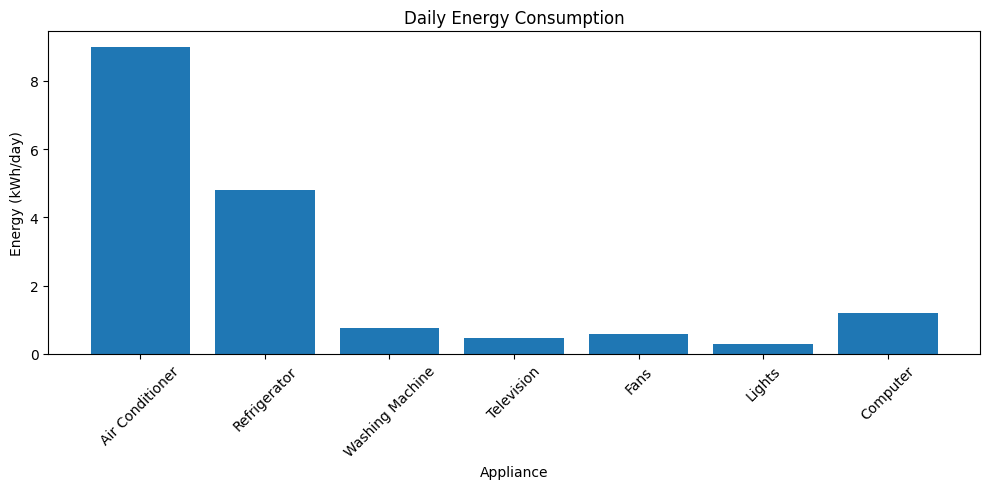

In [20]:
# Step 13 : Visualalizing the Dashboard:(Energy Chart)
plt.figure(figsize=(10, 5))

plt.bar(
    df["Appliance"],
    df["Daily_Energy_kWh"]
)

plt.title("Daily Energy Consumption")
plt.xlabel("Appliance")
plt.ylabel("Energy (kWh/day)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

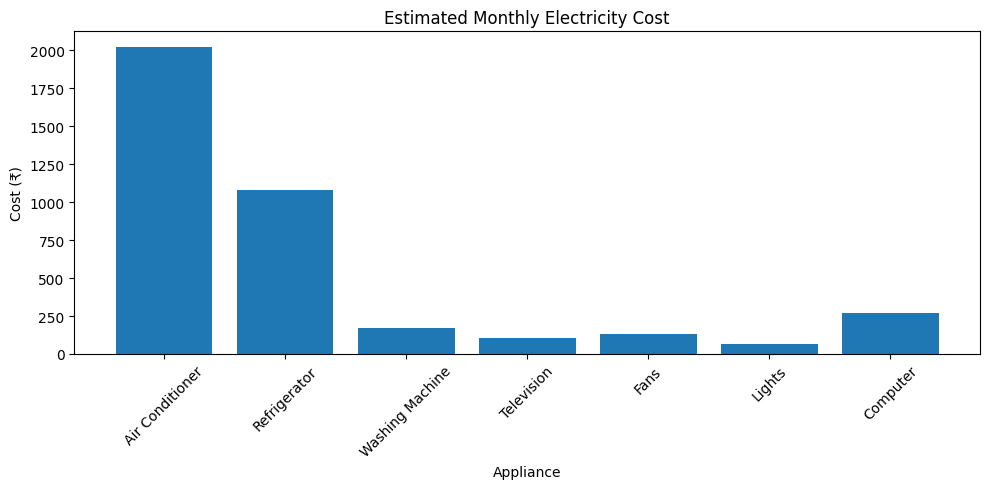

In [21]:
# Step 14 : Monthly Cost Chart:
plt.figure(figsize=(10, 5))

plt.bar(
    df["Appliance"],
    df["Monthly_Cost_INR"]
)

plt.title("Estimated Monthly Electricity Cost")
plt.xlabel("Appliance")
plt.ylabel("Cost (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Step 15 : Builded the RAG knowledge base:
# GreenPulse AI - Sustainability Knowledge Base

knowledge_base = [
    {
        "topic": "Air Conditioner",
        "information": "Using an air conditioner efficiently can reduce electricity consumption. Avoid unnecessary operation, keep doors and windows closed, clean filters regularly, and use an efficient temperature setting."
    },
    {
        "topic": "Refrigerator",
        "information": "Avoid opening the refrigerator unnecessarily. Keep the door seal in good condition and allow sufficient space around the appliance for proper ventilation."
    },
    {
        "topic": "Washing Machine",
        "information": "Using full loads and avoiding unnecessary washing cycles can reduce electricity and water consumption."
    },
    {
        "topic": "Lighting",
        "information": "Switch off lights when rooms are unoccupied. Energy-efficient LED lighting generally uses less electricity than traditional lighting."
    },
    {
        "topic": "Television",
        "information": "Turn off televisions completely when they are not being used instead of leaving them in standby mode."
    },
    {
        "topic": "Computer",
        "information": "Use sleep or power-saving modes when a computer is not actively being used. Shut down devices when they are not needed for long periods."
    },
    {
        "topic": "Energy Conservation",
        "information": "Reducing unnecessary appliance usage, improving energy efficiency, and monitoring consumption can help reduce electricity use, energy costs, and associated emissions."
    }
]

knowledge_df = pd.DataFrame(knowledge_base)

knowledge_df

,topic,information
0,Air Conditioner,Using an air conditioner efficiently can reduc...
1,Refrigerator,Avoid opening the refrigerator unnecessarily. ...
2,Washing Machine,Using full loads and avoiding unnecessary wash...
3,Lighting,Switch off lights when rooms are unoccupied. E...
4,Television,Turn off televisions completely when they are ...
5,Computer,Use sleep or power-saving modes when a compute...
6,Energy Conservation,"Reducing unnecessary appliance usage, improvin..."


In [23]:
# Step 16 : Creating the RAG Retrieval function:
def retrieve_knowledge(query):

    query = query.lower()

    results = []

    for item in knowledge_base:
        text = (
            item["topic"] + " " +
            item["information"]
        ).lower()

        if any(word in text for word in query.split()):
            results.append(item["information"])

    return results


query = "How can I reduce air conditioner electricity consumption?"

results = retrieve_knowledge(query)

print("Retrieved Knowledge:")
print()

for result in results:
    print("-", result)

Retrieved Knowledge:

- Using an air conditioner efficiently can reduce electricity consumption. Avoid unnecessary operation, keep doors and windows closed, clean filters regularly, and use an efficient temperature setting.
- Avoid opening the refrigerator unnecessarily. Keep the door seal in good condition and allow sufficient space around the appliance for proper ventilation.
- Using full loads and avoiding unnecessary washing cycles can reduce electricity and water consumption.
- Switch off lights when rooms are unoccupied. Energy-efficient LED lighting generally uses less electricity than traditional lighting.
- Turn off televisions completely when they are not being used instead of leaving them in standby mode.
- Use sleep or power-saving modes when a computer is not actively being used. Shut down devices when they are not needed for long periods.
- Reducing unnecessary appliance usage, improving energy efficiency, and monitoring consumption can help reduce electricity use, energy

In [24]:
# Step 17 : Connecting RAG with your GreenPulse data:
def greenpulse_analysis():

    top = df.loc[
        df["Daily_Energy_kWh"].idxmax()
    ]

    return {
        "highest_consumer": top["Appliance"],
        "daily_energy": top["Daily_Energy_kWh"],
        "monthly_energy": df["Monthly_Energy_kWh"].sum(),
        "monthly_cost": df["Monthly_Cost_INR"].sum(),
        "monthly_co2": df["Monthly_CO2_kg"].sum(),
        "recommendation": top["AI_Recommendation"]
    }


analysis = greenpulse_analysis()

analysis

{'highest_consumer': 'Air Conditioner',
 'daily_energy': np.float64(9.0),
 'monthly_energy': np.float64(513.9),
 'monthly_cost': np.float64(3854.25),
 'monthly_co2': np.float64(359.73),
 'recommendation': 'Reduce unnecessary AC usage, maintain an efficient temperature setting and keep doors/windows closed.'}

In [25]:
# Step 18 : Creating the GreenPulse AI Assistant:
def greenpulse_ai(question):

    knowledge = retrieve_knowledge(question)

    top = df.loc[
        df["Daily_Energy_kWh"].idxmax()
    ]

    print("🌱 GREENPULSE AI")
    print("=" * 45)

    print(f"\nYour highest energy consumer is: {top['Appliance']}")
    print(
        f"It uses approximately "
        f"{top['Daily_Energy_kWh']:.2f} kWh/day."
    )

    print("\n AI Recommendation:")
    print(top["AI_Recommendation"])

    print("\n Retrieved Sustainability Knowledge:")

    if knowledge:
        for item in knowledge[:3]:
            print("-", item)
    else:
        print(
            "No specific knowledge was found. "
            "Consider reducing unnecessary energy consumption."
        )

In [ ]:
# Step 19 : Testing-1
greenpulse_ai(
    "How can I reduce my electricity consumption?"
)

🌱 GREENPULSE AI

Your highest energy consumer is: Air Conditioner
It uses approximately 9.00 kWh/day.

 AI Recommendation:
Reduce unnecessary AC usage, maintain an efficient temperature setting and keep doors/windows closed.

 Retrieved Sustainability Knowledge:
- Using an air conditioner efficiently can reduce electricity consumption. Avoid unnecessary operation, keep doors and windows closed, clean filters regularly, and use an efficient temperature setting.
- Avoid opening the refrigerator unnecessarily. Keep the door seal in good condition and allow sufficient space around the appliance for proper ventilation.
- Using full loads and avoiding unnecessary washing cycles can reduce electricity and water consumption.


In [27]:
# Testing - 2:
greenpulse_ai(
    "How can I reduce AC electricity consumption?"
)

🌱 GREENPULSE AI

Your highest energy consumer is: Air Conditioner
It uses approximately 9.00 kWh/day.

 AI Recommendation:
Reduce unnecessary AC usage, maintain an efficient temperature setting and keep doors/windows closed.

 Retrieved Sustainability Knowledge:
- Using an air conditioner efficiently can reduce electricity consumption. Avoid unnecessary operation, keep doors and windows closed, clean filters regularly, and use an efficient temperature setting.
- Avoid opening the refrigerator unnecessarily. Keep the door seal in good condition and allow sufficient space around the appliance for proper ventilation.
- Using full loads and avoiding unnecessary washing cycles can reduce electricity and water consumption.


In [28]:
# Testing - 3:
greenpulse_ai(
    "How can I save energy using lights?"
)

🌱 GREENPULSE AI

Your highest energy consumer is: Air Conditioner
It uses approximately 9.00 kWh/day.

 AI Recommendation:
Reduce unnecessary AC usage, maintain an efficient temperature setting and keep doors/windows closed.

 Retrieved Sustainability Knowledge:
- Using an air conditioner efficiently can reduce electricity consumption. Avoid unnecessary operation, keep doors and windows closed, clean filters regularly, and use an efficient temperature setting.
- Avoid opening the refrigerator unnecessarily. Keep the door seal in good condition and allow sufficient space around the appliance for proper ventilation.
- Using full loads and avoiding unnecessary washing cycles can reduce electricity and water consumption.


In [29]:
# Testing - 4:
greenpulse_ai(
    "How can I reduce refrigerator energy usage?"
)

🌱 GREENPULSE AI

Your highest energy consumer is: Air Conditioner
It uses approximately 9.00 kWh/day.

 AI Recommendation:
Reduce unnecessary AC usage, maintain an efficient temperature setting and keep doors/windows closed.

 Retrieved Sustainability Knowledge:
- Using an air conditioner efficiently can reduce electricity consumption. Avoid unnecessary operation, keep doors and windows closed, clean filters regularly, and use an efficient temperature setting.
- Avoid opening the refrigerator unnecessarily. Keep the door seal in good condition and allow sufficient space around the appliance for proper ventilation.
- Using full loads and avoiding unnecessary washing cycles can reduce electricity and water consumption.


In [31]:
# Step 20 : Creating the Streamlit App:
df.to_csv("greenpulse_energy_data.csv", index=False)

print("Dataset saved successfully!")


Dataset saved successfully!


In [34]:
# Step 21: Installing Streamlit:
!pip install streamlit pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 88.8 MB/s eta 0:00:00


In [36]:
# Step 21 (B) : Creating the Project Folder:
!mkdir GreenPulse-AI

In [38]:
# Downloading:
from google.colab import files
files.download('greenpulse_energy_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# Step 21 (C) : Creating the APP.py:
%%writefile GreenPulse-AI/app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Re-define or load necessary data and functions for the standalone app
# In a real Streamlit app, you would typically load your data here.
try:
    df = pd.read_csv('greenpulse_energy_data.csv')
except FileNotFoundError:
    st.error("Error: greenpulse_energy_data.csv not found. Please ensure it's in the same directory as app.py or provide the correct path.")
    st.stop()

# Re-define functions if they are not available globally when running app.py standalone
def retrieve_knowledge(query):
    # This is a placeholder, you'd need your actual knowledge_base here
    knowledge_base = [
        {"topic": "Air Conditioner", "information": "Using an air conditioner efficiently can reduce electricity consumption. Avoid unnecessary operation, keep doors and windows closed, clean filters regularly, and use an efficient temperature setting."},
        {"topic": "Refrigerator", "information": "Avoid opening the refrigerator unnecessarily. Keep the door seal in good condition and allow sufficient space around the appliance for proper ventilation."},
        {"topic": "Washing Machine", "information": "Using full loads and avoiding unnecessary washing cycles can reduce electricity and water consumption."},
        {"topic": "Lighting", "information": "Switch off lights when rooms are unoccupied. Energy-efficient LED lighting generally uses less electricity than traditional lighting."},
        {"topic": "Television", "information": "Turn off televisions completely when they are not being used instead of leaving them in standby mode."},
        {"topic": "Computer", "information": "Use sleep or power-saving modes when a computer is not actively being used. Shut down devices when they are not needed for long periods."},
        {"topic": "Energy Conservation", "information": "Reducing unnecessary appliance usage, improving energy efficiency, and monitoring consumption can help reduce electricity use, energy costs, and associated emissions."}
    ]
    query = query.lower()
    results = []
    for item in knowledge_base:
        text = (item["topic"] + " " + item["information"]).lower()
        if any(word in text for word in query.split()):
            results.append(item["information"])
    return results

def greenpulse_ai(question):
    knowledge = retrieve_knowledge(question)
    top = df.loc[df["Daily_Energy_kWh"].idxmax()]

    st.header("🌱 GREENPULSE AI")
    st.write("=" * 45)

    st.subheader(f"Your highest energy consumer is: {top['Appliance']}")
    st.write(f"It uses approximately {top['Daily_Energy_kWh']:.2f} kWh/day.")

    st.subheader("AI Recommendation:")
    st.write(top["AI_Recommendation"])

    st.subheader("Retrieved Sustainability Knowledge:")
    if knowledge:
        for item in knowledge[:3]:
            st.write(f"- {item}")
    else:
        st.write("No specific knowledge was found. Consider reducing unnecessary energy consumption.")

# Streamlit app layout
st.set_page_config(layout="wide")

st.title("GreenPulse AI Energy Analysis Dashboard")

# Display overall report
st.subheader("Overall GreenPulse AI Report")
st.write(f"Total daily energy: {df['Daily_Energy_kWh'].sum():.2f} kWh")
st.write(f"Monthly energy: {df['Monthly_Energy_kWh'].sum():.2f} kWh")
st.write(f"Estimated monthly cost: ₹{df['Monthly_Cost_INR'].sum():.2f}")
st.write(f"Estimated monthly CO₂: {df['Monthly_CO2_kg'].sum():.2f} kg")

# Daily Energy Consumption Chart
st.subheader("Daily Energy Consumption")
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(df["Appliance"], df["Daily_Energy_kWh"])
ax1.set_title("Daily Energy Consumption")
ax1.set_xlabel("Appliance")
ax1.set_ylabel("Energy (kWh/day)")
plt.xticks(rotation=45)
st.pyplot(fig1)

# Monthly Cost Chart
st.subheader("Estimated Monthly Electricity Cost")
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(df["Appliance"], df["Monthly_Cost_INR"])
ax2.set_title("Estimated Monthly Electricity Cost")
ax2.set_xlabel("Appliance")
ax2.set_ylabel("Cost (₹)")
plt.xticks(rotation=45)
st.pyplot(fig2)

st.subheader("Ask GreenPulse AI a question:")
user_question = st.text_input("Enter your question:", "How can I reduce my electricity consumption?")
if st.button("Get Recommendation"):
    greenpulse_ai(user_question)


Writing GreenPulse-AI/app.py


In [1]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.8 MB/s eta 0:00:00


In [13]:
# Step 23 : (1) Start Streamlit:
!streamlit run GreenPulse-AI/app.py > /content/streamlit.log 2>&1 &

In [9]:
# (3) : Authentication Successfull
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_NGROK_AUTHTOKEN")
print("Authentication successfull")

Authentication successfull


In [15]:
# Step 24 : Start GreenPulse AI:
from pyngrok import ngrok

# Start Streamlit
!streamlit run GreenPulse-AI/app.py > /content/streamlit.log 2>&1 &

print("Starting GreenPulse AI...")

Starting GreenPulse AI...


In [16]:
from pyngrok import ngrok

ngrok.set_auth_token("3Ja5ywoIVh3TtxziJEeoVdtSyKc_5GVt5jsCEaYGi8f1Huk8")

print("✅ ngrok token configured")

✅ ngrok token configured


In [17]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🌱 GreenPulse AI is LIVE!")
print("🔗 Open this link:", public_url)

🌱 GreenPulse AI is LIVE!
🔗 Open this link: NgrokTunnel: "https://wince-praying-crudeness.ngrok-free.dev" -> "http://localhost:8501"


In [18]:
!cat /content/streamlit.log

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: GreenPulse-AI/app.py


In [20]:
!find /content -name "app.py" -type f

In [22]:
# ReCreate the app.py:
import os

os.makedirs("/content/GreenPulse-AI", exist_ok=True)

app_code = r'''
import streamlit as st
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

st.set_page_config(
    page_title="GreenPulse AI",
    page_icon="🌱",
    layout="wide"
)

st.title("GreenPulse AI")
st.subheader("Intelligent Energy Optimization & Carbon Reduction Assistant")

st.write(
    "GreenPulse AI analyzes energy consumption, identifies "
    "high-consumption appliances and provides sustainability recommendations."
)

# Create dataset
data = {
    "Appliance": [
        "Air Conditioner",
        "Refrigerator",
        "Washing Machine",
        "Television",
        "Fans",
        "Lights",
        "Computer"
    ],
    "Hours_Per_Day": [6, 24, 1.5, 4, 8, 5, 6],
    "Power_Watts": [1500, 200, 500, 120, 75, 60, 200]
}

df = pd.DataFrame(data)

# Energy calculations
df["Daily_Energy_kWh"] = (
    df["Hours_Per_Day"] * df["Power_Watts"] / 1000
)

df["Monthly_Energy_kWh"] = (
    df["Daily_Energy_kWh"] * 30
)

ELECTRICITY_RATE = 7.5
EMISSION_FACTOR = 0.7

df["Monthly_Cost_INR"] = (
    df["Monthly_Energy_kWh"] * ELECTRICITY_RATE
)

df["Monthly_CO2_kg"] = (
    df["Monthly_Energy_kWh"] * EMISSION_FACTOR
)

# Machine learning clustering
features = df[
    ["Hours_Per_Day", "Power_Watts", "Daily_Energy_kWh"]
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_energy = (
    df.groupby("Cluster")["Daily_Energy_kWh"]
    .mean()
    .sort_values()
)

level_mapping = {
    cluster_energy.index[0]: "Low",
    cluster_energy.index[1]: "Medium",
    cluster_energy.index[2]: "High"
}

df["Consumption_Level"] = df["Cluster"].map(level_mapping)

# Recommendations
def recommendation(appliance):
    recommendations = {
        "Air Conditioner":
        "Reduce unnecessary AC usage, maintain an efficient temperature setting and keep doors/windows closed.",
        "Refrigerator":
        "Avoid unnecessary door opening and check the door seal regularly.",
        "Washing Machine":
        "Use full loads and avoid unnecessary washing cycles.",
        "Television":
        "Switch off the television completely when it is not being used.",
        "Fans":
        "Switch off fans in unoccupied rooms.",
        "Lights":
        "Switch off unused lights and consider energy-efficient LED lighting.",
        "Computer":
        "Enable sleep or power-saving mode when the computer is not actively being used."
    }

    return recommendations.get(
        appliance,
        "Consider reducing unnecessary energy usage."
    )

df["AI_Recommendation"] = df["Appliance"].apply(recommendation)

# Summary
total_daily = df["Daily_Energy_kWh"].sum()
total_monthly = df["Monthly_Energy_kWh"].sum()
total_cost = df["Monthly_Cost_INR"].sum()
total_co2 = df["Monthly_CO2_kg"].sum()

top = df.loc[df["Daily_Energy_kWh"].idxmax()]

# Dashboard
st.markdown("---")
st.header("Energy Overview")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Daily Energy", f"{total_daily:.2f} kWh")

with col2:
    st.metric("Monthly Energy", f"{total_monthly:.2f} kWh")

with col3:
    st.metric("Estimated Cost", f"₹{total_cost:.2f}")

with col4:
    st.metric("Estimated CO₂", f"{total_co2:.2f} kg")

st.markdown("---")
st.header("Highest Energy Consumer")

st.write(f"### {top['Appliance']}")
st.write(f"Daily consumption: **{top['Daily_Energy_kWh']:.2f} kWh**")
st.write(f"Monthly consumption: **{top['Monthly_Energy_kWh']:.2f} kWh**")
st.write(f"Consumption level: **{top['Consumption_Level']}**")

st.markdown("---")
st.header("GreenPulse AI Recommendation")
st.info(top["AI_Recommendation"])

st.markdown("---")
st.header("⚡ Daily Energy Consumption")

chart_data = df.set_index("Appliance")["Daily_Energy_kWh"]
st.bar_chart(chart_data)

st.markdown("---")
st.header("Detailed Analysis")

display_columns = [
    "Appliance",
    "Hours_Per_Day",
    "Power_Watts",
    "Daily_Energy_kWh",
    "Monthly_Energy_kWh",
    "Monthly_Cost_INR",
    "Monthly_CO2_kg",
    "Consumption_Level"
]

st.dataframe(
    df[display_columns],
    use_container_width=True
)

st.markdown("---")
st.header("Ask GreenPulse AI")

question = st.text_input(
    "Ask a sustainability question:",
    placeholder="How can I reduce my electricity consumption?"
)

if st.button("Get Recommendation"):

    q = question.lower()

    if "ac" in q or "air conditioner" in q:
        answer = recommendation("Air Conditioner")

    elif "light" in q:
        answer = recommendation("Lights")

    elif "refrigerator" in q:
        answer = recommendation("Refrigerator")

    elif "washing" in q:
        answer = recommendation("Washing Machine")

    elif "computer" in q:
        answer = recommendation("Computer")

    elif "fan" in q:
        answer = recommendation("Fans")

    elif "television" in q or "tv" in q:
        answer = recommendation("Television")

    else:
        answer = (
            f"Your highest energy consumer is {top['Appliance']}. "
            f"Focus on reducing unnecessary usage of this appliance first."
        )

    st.success(answer)

st.markdown("---")
st.caption(
    "GreenPulse AI | AI for Sustainability | Prototype Project"
)
'''

with open("/content/GreenPulse-AI/app.py", "w") as f:
    f.write(app_code)

print("GreenPulse-AI folder created")
print("app.py created successfully")

GreenPulse-AI folder created
app.py created successfully


In [23]:
# Verifying :
!ls -l /content/GreenPulse-AI/

total 8
-rw-r--r-- 1 root root 5297 Sep 20 07:03 app.py


In [24]:
# Step 25 : Starting GreenPulse AI:
!streamlit run /content/GreenPulse-AI/app.py > /content/streamlit.log 2>&1 &

In [25]:
!cat /content/streamlit.log



2026-09-20 07:06:44.216 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.67.12.184:8501



In [26]:
# Step 26 : Again Creating GreenPulse Public Link:
from pyngrok import ngrok

# Close any old tunnels
ngrok.kill()

# Create a new public tunnel to Streamlit
public_url = ngrok.connect(8501)

print("GreenPulse AI is LIVE!")
print("Open this link:", public_url)

GreenPulse AI is LIVE!
Open this link: NgrokTunnel: "https://wince-praying-crudeness.ngrok-free.dev" -> "http://localhost:8501"


In [27]:
# Downloading the file:
from google.colab import files

files.download("/content/GreenPulse-AI/app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# Thank You